# Лабораторная работа № 4
## *Acoustic event analysis*
по курсу Аудиоаналитика  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Шуранов Евгений В.  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

In [1]:
import os
import os.path as path
import random
import pickle
from enum import Enum
from typing import NoReturn, Optional
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from IPython.display import Audio

device = "cuda" if torch.cuda.is_available() else "cpu"
cpu_count = os.cpu_count()
num_workers = cpu_count if device == "cpu" else 0
device

'cuda'

## загрузка и осмотр датасета

In [4]:
import kagglehub
base_folder = kagglehub.dataset_download("ivanyankin/audionalysis-aed")
res_folder = './'
base_folder

'/home/ext-yankin@ad.speechpro.com/.cache/kagglehub/datasets/ivanyankin/audionalysis-aed/versions/1'

In [3]:
train_folder = path.join(base_folder, "train_wav/train")
train_csv = path.join(base_folder, "train_labels.csv")
train_pickle = path.join(res_folder, "datasets/train.pickle")
labels_pickle = path.join(res_folder, "datasets/labels.pickle")
feat_pickle = path.join(res_folder, "features/features.pkl")

In [4]:
df = pd.read_csv(train_csv)
df.head(3)

,fname,label
0,8bcbcc394ba64fe85ed4.wav,Finger_snapping
1,00d77b917e241afa06f1.wav,Squeak
2,17bb93b73b8e79234cb3.wav,Electric_piano


### Спектрограмма

In [5]:
sample_rate = 11025
files = os.listdir(train_folder)
filename = random.choice(files)

In [6]:
filename = random.choice(files)
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=None)
wav_data, sr

(array([1.9831712e-04, 2.1270597e-04, 5.9370603e-04, ..., 1.4548196e-04,
        8.5743552e-05, 2.9170667e-04], dtype=float32),
 16000)

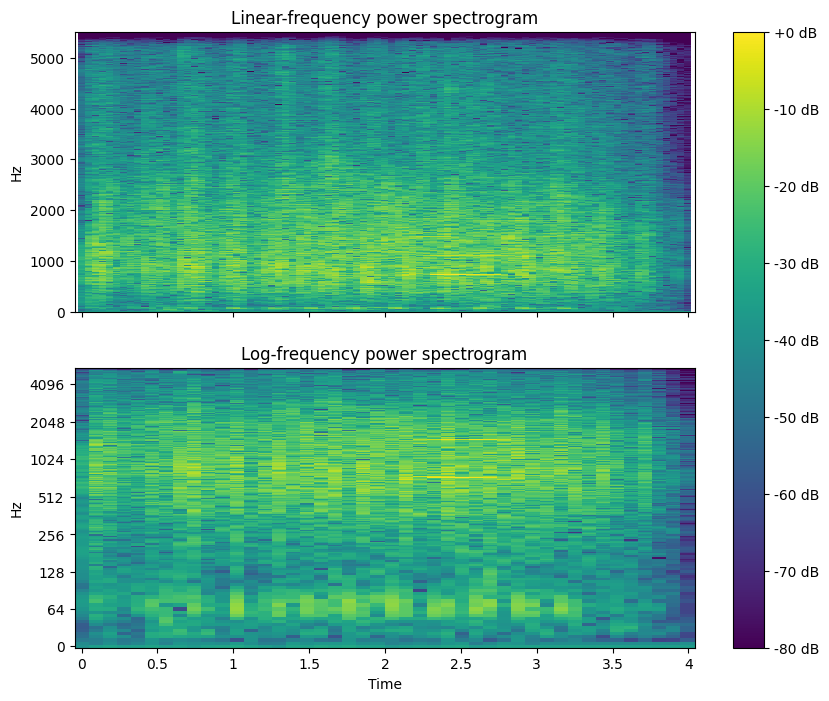

In [7]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

# draw linear-frequency spectrogram
hop_length = 512
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img1 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_top,
    x_axis='time',
    y_axis='linear',
    cmap=cmap,
)
ax_top.set(title='Linear-frequency power spectrogram')
ax_top.label_outer()

# draw log-frequency spectrogram
hop_length = 1024
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img2 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_bottom,
    x_axis='time',
    y_axis='log',
    cmap=cmap,
)
ax_bottom.set(title='Log-frequency power spectrogram')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

### Mel-спектрограмма

In [8]:
# melspectrogram parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

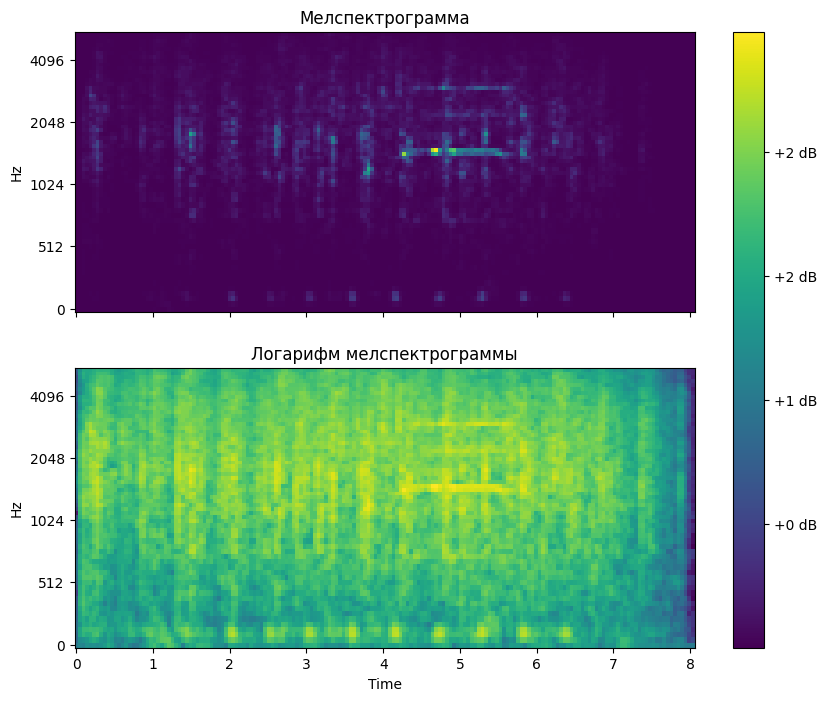

In [9]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

mel_spec = librosa.feature.melspectrogram(
    y=wav_data,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels, 
    fmax=sample_rate // 2
)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

img1 = librosa.display.specshow(
    mel_spec,
    sr=sr,
    fmax=sr // 2,
    ax=ax_top,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_top.set(title='Мелспектрограмма')
ax_top.label_outer()

D = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(
    D,
    sr=sr,
    fmax=sr // 2,
    ax=ax_bottom,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_bottom.set(title='Логарифм мелспектрограммы')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

## извлечение признаков

In [ ]:
def apply_pre_emphasis(y, coef=0.97):
    return np.append(y[0], y[1:] - coef * y[:-1])

def compute_log_mel(wav_data: np.ndarray, sr: int, n_fft: int, 
                    hop_length: int, n_mels: int, target_len: int = 172) -> np.ndarray:

    wav_data = apply_pre_emphasis(wav_data)

    wav_data = wav_data / (np.max(np.abs(wav_data)) + 1e-9)

    mel_spec = librosa.feature.melspectrogram(
        y=wav_data, sr=sr, n_fft=n_fft, 
        hop_length=hop_length, n_mels=n_mels, fmax=sr // 2
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    if log_mel.shape[1] < target_len:
        pad_width = target_len - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mel = log_mel[:, :target_len]

    return log_mel

def process_single_audio(file_name, path_to_files, sr, n_fft, hop_length, n_mels, label_id=None):
    file_path = os.path.join(path_to_files, file_name)
    
    wav, current_sr = librosa.load(file_path, sr=sr, res_type='kaiser_fast')
    wav, _ = librosa.effects.trim(wav)
    
    log_mel_spec = compute_log_mel(wav, current_sr, n_fft, hop_length, n_mels)
    
    result = {
        'fname': file_name,
        'feature': log_mel_spec.astype(np.float32),
    }
    if label_id is not None:
        result['label_id'] = label_id
        
    return result

In [11]:
duration_sec = 2
sample_rate = 16000
n_fft = 1024
hop_length = n_fft // 4 # 256
n_mels = 128

window_size = int((duration_sec * sample_rate) / hop_length)

In [12]:
from joblib import Parallel, delayed

if not os.path.exists(feat_pickle):
    meta = pd.read_csv(train_csv, skiprows=1, names=['fname', 'label'])
    uniq_labels = np.sort(meta['label'].unique())
    label_to_id = {label: i for i, label in enumerate(uniq_labels)}

    feats = Parallel(n_jobs=2)(
        delayed(process_single_audio)(
            file_name=row.fname,
            path_to_files=train_folder,
            sr=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            label_id=label_to_id[row.label]
        ) 
        for row in tqdm(meta.itertuples(index=False), total=len(meta))
    )

    with open(feat_pickle, 'wb') as f:
        pickle.dump(feats, f)

## алгоритм детектирования

### 0. настройка воспроизводимости
- по мануалу: https://pytorch.org/docs/stable/notes/randomness.html

In [13]:
def set_random_state(random_state:int=0) -> NoReturn:
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


random_state = 42
set_random_state(random_state)
torch.use_deterministic_algorithms(True)

In [ ]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8
%env PYTHONHASHSEED=42

env: CUBLAS_WORKSPACE_CONFIG=:4096:8
env: PYTHONHASHSEED=42


### 1. подготовка датасета

In [15]:
class EventDetectionDataset(Dataset):
    def __init__(self, x, y=None, window_size=172, is_train=True):
        self.x = x
        self.y = y
        self.N = window_size
        self.is_train = is_train

    def __len__(self):
        return len(self.x)

    def _prepare_sample(self, feature):
        # padding
        if feature.shape[1] < self.N:
            pad_width = self.N - feature.shape[1]
            feature = np.pad(feature, ((0, 0), (0, pad_width)), mode='constant')
        
        # random crop для трейна, start для валидации
        if feature.shape[1] > self.N:
            if self.is_train:
                max_shift = feature.shape[1] - self.N
                start = np.random.randint(0, max_shift + 1)
            else:
                start = 0
            sample = feature[:, start:start + self.N]
        else:
            sample = feature
            
        return sample[np.newaxis, :, :]

    def __getitem__(self, idx):
        x_sample = self._prepare_sample(self.x[idx])
        x_tensor = torch.from_numpy(x_sample).float()
        
        if self.y is not None:
            y_tensor = torch.tensor(self.y[idx], dtype=torch.long)
            return x_tensor, y_tensor

        return x_tensor

In [16]:
train_data = pickle.load(open(train_pickle, "rb"))
label_to_id = pickle.load(open(labels_pickle, "rb"))
id_to_label = [label for label, i in label_to_id.items()]

In [17]:
from sklearn.model_selection import train_test_split

all_features = [row['feature'] for row in train_data]
all_labels = [row['label_id'] for row in train_data]

x_tr, x_val, y_tr, y_val = train_test_split(
    all_features, 
    all_labels, 
    test_size=800,
    stratify=all_labels,
    random_state=random_state
)

y_tr = np.array(y_tr)
y_val = np.array(y_val)

train_dset = EventDetectionDataset(x_tr, y_tr, is_train=True, window_size=window_size)
val_dset = EventDetectionDataset(x_val, y_val, is_train=False, window_size=window_size)

train_loader = DataLoader(train_dset, batch_size=32, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dset, batch_size=32, shuffle=False, num_workers=num_workers)

In [18]:
set_random_state(random_state)
sample_x, sample_y = random.choice(val_dset)
sample_y.item(), id_to_label[sample_y]

(26, 'Laughter')

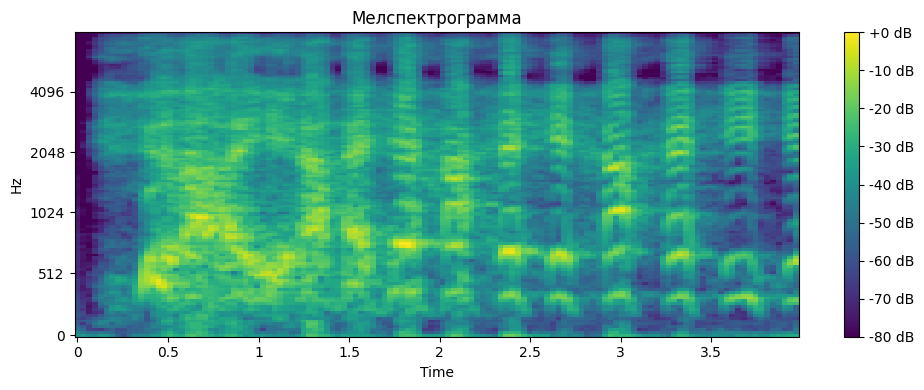

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

img = librosa.display.specshow(
    sample_x[0].numpy(force=True),
    sr=sample_rate,
    fmax=sample_rate // 2,
    ax=ax,
    x_axis='time',
    y_axis='mel',
    cmap="viridis",
)
ax.set(title='Мелспектрограмма')
ax.label_outer()

fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.tight_layout()
plt.show()

### 2. архитектура нейронной сети

In [20]:
class BaseNetwork(nn.Module):
    def __init__(self, num_classes, input_shape=None):
        super().__init__()
        
        def conv_block(in_f, out_f):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_f),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout(0.2)
            )

        self.features = nn.Sequential(
            conv_block(1, 64),      # -> (64, 64, 86)
            conv_block(64, 128),    # -> (128, 32, 43)
            conv_block(128, 256),   # -> (256, 16, 21)
            conv_block(256, 128)    # -> (128, 8, 10)
        )

        self.flat = nn.Flatten()
        
        with torch.no_grad():
            dummy_output = self.features(torch.zeros(1, *input_shape))
            self.n_flatten = dummy_output.view(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Linear(self.n_flatten, 512), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flat(x)
        x = self.fc(x)
        return x

### 3. обучение модели

In [21]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Valid Loss', linewidth=2)
    ax1.set_title('Training and Valid Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 41/50 | Best Val Acc: 0.6613


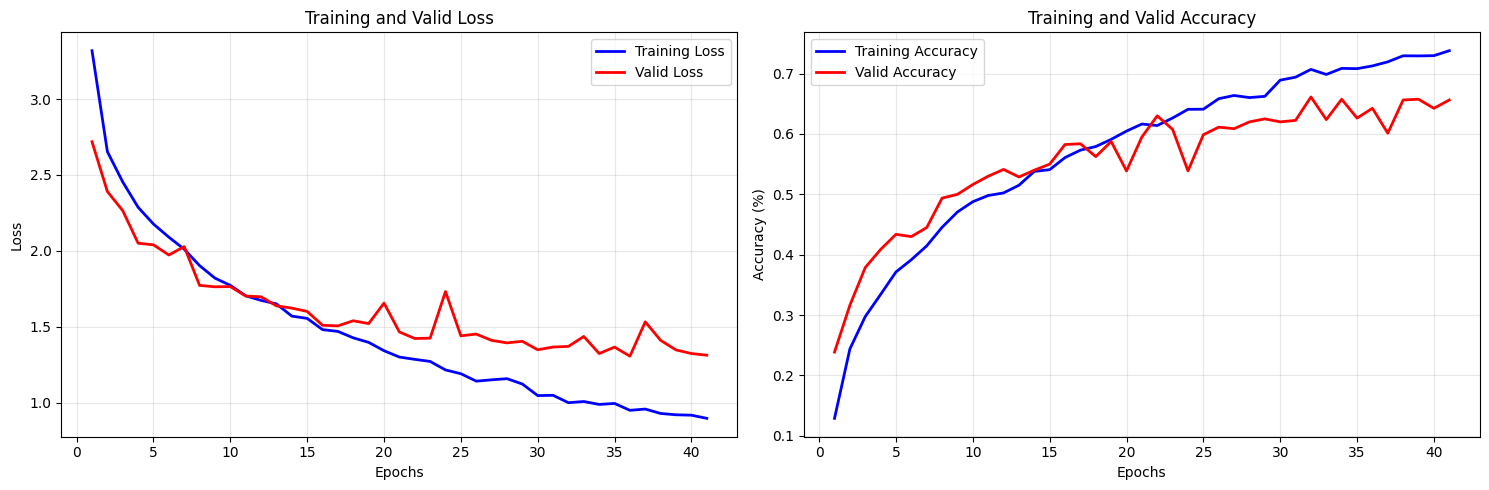

Stopping on epoch 40.
Total time: 277.43s


In [22]:
from tqdm.auto import tqdm
from IPython.display import clear_output

train_loss = []
val_loss = []
train_acc = []
val_acc = []
best_val_loss = float('inf')
patience = 5
stop_counter = 0

set_random_state(random_state)
n_epoch = 50

network = BaseNetwork(num_classes=41, input_shape=(1, n_mels, window_size)).to(device)
optimizer = optim.Adam(network.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

train_loss, val_loss = [], []
train_acc, val_acc = [], []
best_val_acc = 0.0

start_time = time.time()

for e in range(n_epoch):
    # --- TRAINING ---
    network.train()
    loss_list, correct, total = [], 0, 0
    
    tbar = tqdm(train_loader, desc=f"Epoch {e+1}/{n_epoch} [Train]", leave=False)
    for x, y in tbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = network(x)
        loss = criterion(output, y.long())
        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
        correct += (output.argmax(1) == y).sum().item()
        total += y.size(0)
        tbar.set_postfix(loss=np.mean(loss_list))

    train_loss.append(np.mean(loss_list))
    train_acc.append(correct / total)

    # --- VALIDATION ---
    network.eval()
    v_loss_list, v_correct, v_total = [], 0, 0
    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {e+1} [Val]", leave=False):
            x, y = x.to(device), y.to(device)
            output = network(x)
            loss = criterion(output, y.long())
            v_loss_list.append(loss.item())
            v_correct += (output.argmax(1) == y).sum().item()
            v_total += y.size(0)
    

    val_loss.append(np.mean(v_loss_list))
    val_acc.append(v_correct / v_total)

    pd.DataFrame({
        'train_loss': train_loss, 'val_loss': val_loss,
        'train_acc': train_acc, 'val_acc': val_acc
    }).to_csv('./logs/training_history.csv', index=False)

    if val_acc[-1] > best_val_acc:
        best_val_acc = val_acc[-1]
        torch.save(network.state_dict(), './models/best_model_acc.pth')

    clear_output(wait=True) 
    print(f"Epoch {e+1}/{n_epoch} | Best Val Acc: {best_val_acc:.4f}")
    plot_metrics(train_loss, train_acc, val_loss, val_acc)

    current_loss = val_loss[-1]
    
    if current_loss < best_val_loss:
        best_val_loss = current_loss
        stop_counter = 0
        torch.save(network.state_dict(), './models/best_model_loss.pth')
    else:
        stop_counter += 1
        
    if stop_counter >= patience:
        print(f"Stopping on epoch {e}.")
        break

print(f"Total time: {time.time() - start_time:.2f}s")

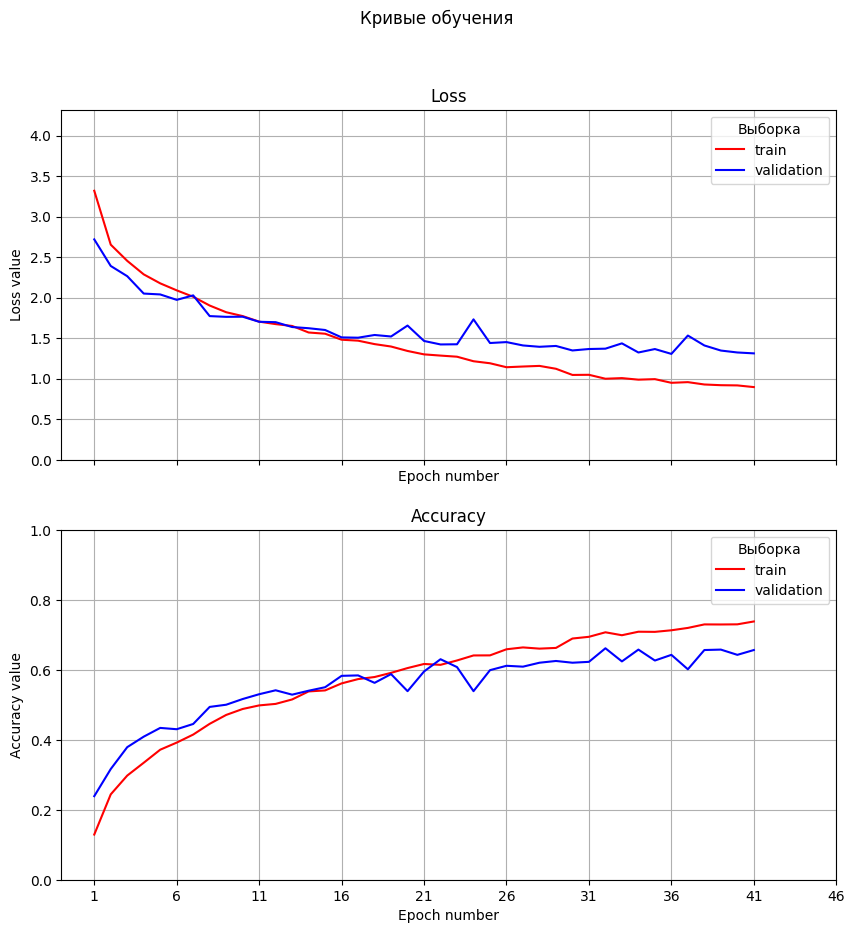

In [23]:
import gc
torch.cuda.empty_cache()
gc.collect()

epochs = range(1, len(val_loss) + 1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## исходное решение

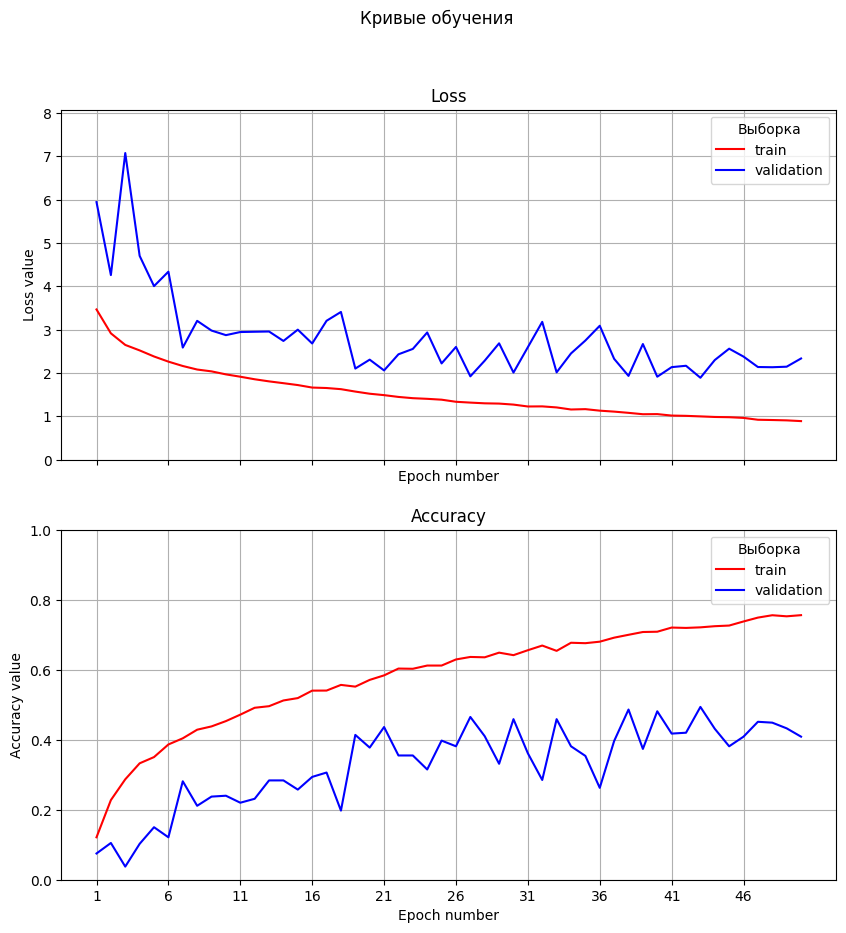

```epoch #1
[train] mean loss: 3.4677881161371866
[train] accuracy:  0.12123694450133114
[val] mean loss:   5.945097351074219
[val] accuracy:    0.075

epoch #2
[train] mean loss: 2.916513812541962
[train] accuracy:  0.2275240630759779
[val] mean loss:   4.261375594139099
[val] accuracy:    0.105

epoch #3
[train] mean loss: 2.649107431372007
[train] accuracy:  0.2869137825107516
[val] mean loss:   7.076955127716064
[val] accuracy:    0.0375

epoch #4
[train] mean loss: 2.522689547141393
[train] accuracy:  0.33258242883473277
[val] mean loss:   4.705143284797669
[val] accuracy:    0.1025

epoch #5
[train] mean loss: 2.382602518796921
[train] accuracy:  0.35039934466516487
[val] mean loss:   4.006146860122681
[val] accuracy:    0.15

epoch #6
[train] mean loss: 2.2636896948019665
[train] accuracy:  0.38644276059799304
[val] mean loss:   4.339523351192474
[val] accuracy:    0.12125

epoch #7
[train] mean loss: 2.162877202530702
[train] accuracy:  0.4040548842924432
[val] mean loss:   2.588106316328049
[val] accuracy:    0.28125

epoch #8
[train] mean loss: 2.0813912391662597
[train] accuracy:  0.4286299406102806
[val] mean loss:   3.2048115968704223
[val] accuracy:    0.21125

epoch #9
[train] mean loss: 2.0387201378742854
[train] accuracy:  0.43805037886545156
[val] mean loss:   2.9805927872657776
[val] accuracy:    0.2375

epoch #10
[train] mean loss: 1.9696949779987336
[train] accuracy:  0.45320499692811794
[val] mean loss:   2.8750412464141846
[val] accuracy:    0.24

epoch #11
[train] mean loss: 1.9155711611111959
[train] accuracy:  0.471636289166496
[val] mean loss:   2.946679449081421
[val] accuracy:    0.22

epoch #12
[train] mean loss: 1.856789224843184
[train] accuracy:  0.4912963342207659
[val] mean loss:   2.953189325332642
[val] accuracy:    0.23125

epoch #13
[train] mean loss: 1.8080644607543945
[train] accuracy:  0.49580176121236946
[val] mean loss:   2.958732545375824
[val] accuracy:    0.28375

epoch #14
[train] mean loss: 1.7662339915831884
[train] accuracy:  0.5121851320909278
[val] mean loss:   2.741084969043732
[val] accuracy:    0.28375

epoch #15
[train] mean loss: 1.7229019234577814
[train] accuracy:  0.518943272578333
[val] mean loss:   3.0013426303863526
[val] accuracy:    0.2575

epoch #16
[train] mean loss: 1.6652554790178935
[train] accuracy:  0.5402416547204587
[val] mean loss:   2.682161217927933
[val] accuracy:    0.29375

epoch #17
[train] mean loss: 1.6547739187876382
[train] accuracy:  0.5404464468564407
[val] mean loss:   3.206479585170746
[val] accuracy:    0.30625

epoch #18
[train] mean loss: 1.6282961477835973
[train] accuracy:  0.5566250255990169
[val] mean loss:   3.410001850128174
[val] accuracy:    0.1975

epoch #19
[train] mean loss: 1.572638467947642
[train] accuracy:  0.5517100143354495
[val] mean loss:   2.103834253549576
[val] accuracy:    0.41375

epoch #20
[train] mean loss: 1.5230358332395553
[train] accuracy:  0.5709604751177555
[val] mean loss:   2.3093817114830015
[val] accuracy:    0.3775

epoch #21
[train] mean loss: 1.4904422730207443
[train] accuracy:  0.5838623796846201
[val] mean loss:   2.0608263850212096
[val] accuracy:    0.43625

epoch #22
[train] mean loss: 1.4490966866413753
[train] accuracy:  0.603317632602908
[val] mean loss:   2.4327284514904024
[val] accuracy:    0.355

epoch #23
[train] mean loss: 1.4201669837037723
[train] accuracy:  0.6027032561949621
[val] mean loss:   2.5570071160793306
[val] accuracy:    0.355

epoch #24
[train] mean loss: 1.405203773578008
[train] accuracy:  0.6119189023141511
[val] mean loss:   2.9365256667137145
[val] accuracy:    0.315

epoch #25
[train] mean loss: 1.3855040078361829
[train] accuracy:  0.6119189023141511
[val] mean loss:   2.222437006235123
[val] accuracy:    0.3975

epoch #26
[train] mean loss: 1.3371475835641224
[train] accuracy:  0.6293262338726193
[val] mean loss:   2.6024180114269257
[val] accuracy:    0.38125

epoch #27
[train] mean loss: 1.3181612312793731
[train] accuracy:  0.6364939586319885
[val] mean loss:   1.9243315219879151
[val] accuracy:    0.465

epoch #28
[train] mean loss: 1.3015832290053369
[train] accuracy:  0.6354699979520786
[val] mean loss:   2.286177563667297
[val] accuracy:    0.41

epoch #29
[train] mean loss: 1.2954737876852354
[train] accuracy:  0.6487814867909072
[val] mean loss:   2.6859671831130982
[val] accuracy:    0.33125

epoch #30
[train] mean loss: 1.2721198605994384
[train] accuracy:  0.641613762031538
[val] mean loss:   2.0113594233989716
[val] accuracy:    0.45875

epoch #31
[train] mean loss: 1.228633882602056
[train] accuracy:  0.6557444194142945
[val] mean loss:   2.5970158159732817
[val] accuracy:    0.36125

epoch #32
[train] mean loss: 1.2310944616794586
[train] accuracy:  0.6690559082531231
[val] mean loss:   3.181568908691406
[val] accuracy:    0.285

epoch #33
[train] mean loss: 1.2068516795833906
[train] accuracy:  0.6539012901904567
[val] mean loss:   2.016216015815735
[val] accuracy:    0.45875

epoch #34
[train] mean loss: 1.1590674668550491
[train] accuracy:  0.6770428015564203
[val] mean loss:   2.4526726067066194
[val] accuracy:    0.38125

epoch #35
[train] mean loss: 1.1671855390071868
[train] accuracy:  0.6758140487405284
[val] mean loss:   2.750713860988617
[val] accuracy:    0.35375

epoch #36
[train] mean loss: 1.1321950261791547
[train] accuracy:  0.6801146835961499
[val] mean loss:   3.091293787956238
[val] accuracy:    0.2625

epoch #37
[train] mean loss: 1.1101278871297837
[train] accuracy:  0.6915830432111407
[val] mean loss:   2.3284138560295107
[val] accuracy:    0.39625

epoch #38
[train] mean loss: 1.0817574582993985
[train] accuracy:  0.6997747286504198
[val] mean loss:   1.9343114376068116
[val] accuracy:    0.48625

epoch #39
[train] mean loss: 1.050000335276127
[train] accuracy:  0.707761621953717
[val] mean loss:   2.66974276304245
[val] accuracy:    0.37375

epoch #40
[train] mean loss: 1.052763006836176
[train] accuracy:  0.7085807904976449
[val] mean loss:   1.915644121170044
[val] accuracy:    0.48125

epoch #41
[train] mean loss: 1.018964444597562
[train] accuracy:  0.7204587343845996
[val] mean loss:   2.1364763379096985
[val] accuracy:    0.4175

epoch #42
[train] mean loss: 1.0124961726367474
[train] accuracy:  0.7194347737046898
[val] mean loss:   2.168208134174347
[val] accuracy:    0.42

epoch #43
[train] mean loss: 0.9999014000097911
[train] accuracy:  0.7210731107925455
[val] mean loss:   1.8915273904800416
[val] accuracy:    0.49375

epoch #44
[train] mean loss: 0.986577462653319
[train] accuracy:  0.7243497849682572
[val] mean loss:   2.3002667248249056
[val] accuracy:    0.43125

epoch #45
[train] mean loss: 0.9810417845845223
[train] accuracy:  0.726192914192095
[val] mean loss:   2.5625289916992187
[val] accuracy:    0.38125

epoch #46
[train] mean loss: 0.964914001027743
[train] accuracy:  0.7378660659430678
[val] mean loss:   2.37952743768692
[val] accuracy:    0.40875

epoch #47
[train] mean loss: 0.9223882074157397
[train] accuracy:  0.7489248412860946
[val] mean loss:   2.1392681419849398
[val] accuracy:    0.45125

epoch #48
[train] mean loss: 0.9162052184343338
[train] accuracy:  0.7556829817734999
[val] mean loss:   2.134575700759888
[val] accuracy:    0.44875

epoch #49
[train] mean loss: 0.9081574966510136
[train] accuracy:  0.7526110997337703
[val] mean loss:   2.1467244207859038
[val] accuracy:    0.4325

epoch #50
[train] mean loss: 0.8911935180425644
[train] accuracy:  0.7558877739094819
[val] mean loss:   2.3365002393722536
[val] accuracy:    0.40875

Execution time: 62.02 seconds
```